# Step 3: Feature Engineering & Model Training
Build a model to predict whether an order will be **Delivered** or **Returned/Cancelled**.

In [1]:
import pandas as pd
import numpy as np
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../ecommerce_orders_cleaned.csv', parse_dates=['order_date'])
print('Loaded shape:', df.shape)
df.head()

Loaded shape: (500, 19)


,order_id,customer_id,customer_age,customer_gender,city,order_date,product,category,quantity,unit_price,discount_pct,discount_amount,revenue,payment_method,order_status,month,year,day_of_week,age_group
0,ORD00001,CUST0091,50.0,Other,Hyderabad,2023-12-25,T-Shirt,Clothing,4,538.49,10.0,215.40,1938.56,Debit Card,Delivered,12,2023,Monday,46-60
1,ORD00002,CUST0009,51.0,Male,Delhi,2023-10-13,Backpack,Accessories,3,1550.96,10.0,465.29,4187.59,Cash on Delivery,Delivered,10,2023,Friday,46-60
2,ORD00003,CUST0125,20.0,Female,Ahmedabad,2023-09-25,Running Shoes,Footwear,1,5713.41,5.0,285.67,5427.74,Cash on Delivery,Returned,9,2023,Monday,18-25
3,ORD00004,CUST0016,56.0,Male,Hyderabad,2023-11-18,Laptop,Electronics,1,49336.10,15.0,7400.41,41935.69,Cash on Delivery,Returned,11,2023,Saturday,46-60
4,ORD00005,CUST0030,55.0,Other,Kolkata,2023-02-15,Backpack,Accessories,1,3207.56,25.0,801.89,2405.67,Net Banking,Delivered,2,2023,Wednesday,46-60


## 1. Create Target Variable

In [2]:
# Target: 1 = Delivered/Shipped (good), 0 = Returned/Cancelled (bad)
df['target'] = df['order_status'].apply(
    lambda x: 1 if x in ['Delivered', 'Shipped'] else 0
)
print('Target distribution:')
print(df['target'].value_counts())
print()
print('Class balance (%):')
print(round(df['target'].value_counts(normalize=True) * 100, 1))

Target distribution:
target
1    442
0     58
Name: count, dtype: int64

Class balance (%):
target
1    88.4
0    11.6
Name: proportion, dtype: float64


## 2. Feature Engineering

In [3]:
# Encode categorical columns
le = LabelEncoder()
cat_cols = ['category', 'city', 'customer_gender', 'payment_method', 'product']

df_model = df.copy()
for col in cat_cols:
    df_model[col + '_enc'] = le.fit_transform(df_model[col].astype(str))

# Select features
feature_cols = [
    'customer_age', 'quantity', 'unit_price', 'discount_pct',
    'discount_amount', 'revenue', 'month',
    'category_enc', 'city_enc', 'customer_gender_enc',
    'payment_method_enc', 'product_enc'
]

X = df_model[feature_cols]
y = df_model['target']

print('Features:', feature_cols)
print('X shape:', X.shape)
print('y shape:', y.shape)

Features: ['customer_age', 'quantity', 'unit_price', 'discount_pct', 'discount_amount', 'revenue', 'month', 'category_enc', 'city_enc', 'customer_gender_enc', 'payment_method_enc', 'product_enc']
X shape: (500, 12)
y shape: (500,)


## 3. Split & Scale

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Fix NaN values with median imputation
imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Train size:', X_train.shape[0])
print('Test size: ', X_test.shape[0])

Train size: 400
Test size:  100


## 4. Train Random Forest Model

In [5]:
model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=8)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 2), '%')
print()
print(classification_report(y_test, y_pred, target_names=['Returned/Cancelled','Delivered/Shipped']))

Accuracy: 88.0 %

                    precision    recall  f1-score   support

Returned/Cancelled       0.00      0.00      0.00        12
 Delivered/Shipped       0.88      1.00      0.94        88

          accuracy                           0.88       100
         macro avg       0.44      0.50      0.47       100
      weighted avg       0.77      0.88      0.82       100



## 5. Feature Importance

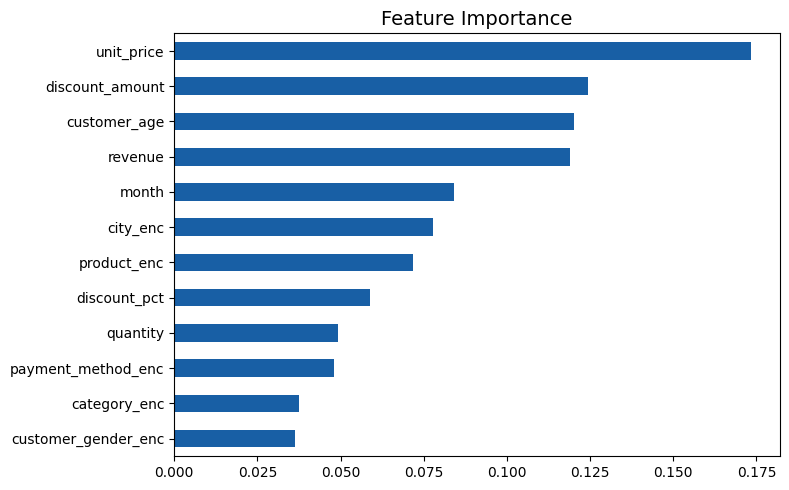

In [6]:
import matplotlib.pyplot as plt

importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='#185FA5')
plt.title('Feature Importance', fontsize=14)
plt.tight_layout()
plt.show()

## 6. Save Model & Scaler

In [7]:
with open('../models/loan_model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('../models/imputer.pkl', 'wb') as f:
    pickle.dump(imputer, f)

with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)

print('Model saved  → models/loan_model.pkl')
print('Scaler saved → models/scaler.pkl')
print('Imputer saved→ models/imputer.pkl')
print('Features saved→ models/feature_names.pkl')

Model saved  → models/loan_model.pkl
Scaler saved → models/scaler.pkl
Imputer saved→ models/imputer.pkl
Features saved→ models/feature_names.pkl
